In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, t
from statsmodels.tsa.stattools import adfuller

plt.style.use('bmh')

import warnings
warnings.filterwarnings('ignore')

# 1. Market Making Strategy and Backtest Engine



In [ ]:
class BacktestEngine:
    def __init__(self):
        # Meta strategy setting
        self.order_offset = None
        self.max_position = None
        self.order_size = None
        self.fill_threshold = None
        self.cash = 5000

        # Other necessary attribute
        self.mid_val_ts = None # a time series Dataframe with two columns ['timestamp', 'mid_val']
        self.roll_hb = None # roll fitter for Huobi

        self.order_history = []
        self.current_order = {'Binance_Bid': [0, 0], 'Binance_Ask': [0, 0],
                              'Huobi_Bid': [0, 0], 'Huobi_Ask': [0, 0]} # Outstanding order price and volume
        self.trade_history = []
        self.current_positions = {'Binance': 0, 'Huobi': 0}

        # Dataframe used
        self.bar_data_bnc = None
        self.bar_data_hb = None
        self.orderbook_bnc = None
        self.orderbook_hb = None

    def load_data(self, bar_bnc_fname, bar_hb_fname, ob_bnc_fname, ob_hb_fname, root_dir='../'):
        '''
        Load and preprocess the market data.

        PARAMS:
            bar_bnc_fname: string, Bar data filename for Binance.
            bar_hb_fname: string, Bar data filename for Huobi.
            ob_bnc_fname: string, Order book data filename for Binance.
            ob_hb_fname: string, Order book data filename for Huobi.
            root_dir: string (end with '/', default: '../')

        RETURN: None
        '''
        bar_bnc = pd.read_csv(root_dir + bar_bnc_fname)
        bar_hb = pd.read_csv(root_dir + bar_hb_fname)
        orderbook_bnc = pd.read_csv(root_dir + ob_bnc_fname)
        orderbook_hb = pd.read_csv(root_dir + ob_hb_fname)

        # Convert the timestamp datatypes
        for df in [bar_bnc, bar_hb, orderbook_bnc, orderbook_hb]:
            df['timestamp'] = pd.to_datetime(df['timestamp'])

        self.bar_bnc = bar_bnc
        self.bar_hb = bar_hb
        self.orderbook_bnc = orderbook_bnc
        self.orderbook_hb = orderbook_hb

    def __calculate_mid_val(self, w=5, min_update_bps=5): # Calculate the mid_val for market making pricing
        '''
        PARAMS:
            w: int, moving average window
        RETURN: None
        '''
        # Calculate the weighted mid price for Binance and Huobi
        wmid_price_bnc = (self.orderbook_bnc['b1']*self.orderbook_bnc['av1'] + orderbook_bnc['a1']*orderbook_bnc['bv1']) / (orderbook_bnc['av1'] + orderbook_bnc['bv1'])

        wmid_price_hb = (orderbook_hb['b1']*orderbook_hb['av1'] + orderbook_hb['a1']*orderbook_hb['bv1']) /(orderbook_hb['av1'] + orderbook_hb['bv1'])

        # Calculate the difference as roll fitter
        self.roll_hb = (wmid_price_bnc - wmid_price_hb).mean().round(4)

        # Initialize mid_val using moving average of binance wmid_price
        if self.mid_val_ts is None:
          mv_wmid_price = wmid_price_bnc.rolling(window=w).mean().round(4).fillna(0)
          self.mid_val_ts = pd.concat([self.orderbook_bnc['timestamp'], mv_wmid_price], axis=1)
          self.mid_val_ts.columns = ['timestamp', 'mid_val']
        else:
          print("The mid_val has been initialized already")

        last_mid_val = 0
        for index, row in self.mid_val_ts.iterrows():
          if row['mid_val'] == 0:
            continue

          if last_mid_val == 0:
            last_mid_val = row['mid_val']
          else:
            changed_bps = 10000 * (row['mid_val'] - last_mid_val) / last_mid_val
            if abs(changed_bps) < min_update_bps:
              self.mid_val_ts.at[index, 'mid_val'] = last_mid_val
            else:
              last_mid_val = row['mid_val']

    def __posval(self, time): # Calculate the position value at time T
        '''
        PARAMS:
          time: datetime(seconds)

        RETURN: None
        '''
        bnc_ob_data = self.orderbook_bnc[self.orderbook_bnc['timestamp'] == time]
        hb_ob_data = self.orderbook_hb[self.orderbook_hb['timestamp'] == time]

        mid_price_bnc = ((bnc_ob_data['a1'] + bnc_ob_data['b1']) / 2).iloc[0]
        mid_price_hb = ((hb_ob_data['a1'] + hb_ob_data['b1']) / 2).iloc[0]

        binance_pos = self.current_positions['Binance']
        huobi_pos = self.current_positions['Huobi']

        return binance_pos * mid_price_bnc + huobi_pos * mid_price_hb


    def __calculate_markout(self): # Calculate the markout
        '''
        markout: the mid_val movement since the trade happens

        RETURN: None
        '''
        time_intervals = [5, 15, 30, 60, 300, 900]
        for interval in time_intervals:
          mid_val_change = self.mid_val_ts['mid_val'].shift(-interval) - self.mid_val_ts['mid_val']

          # Calculate price movement in bps (1 basis point = 0.01%)
          self.mid_val_ts[f'markout_{interval}s'] = ((mid_val_change / self.mid_val_ts['mid_val']) * 10000).round(2)

    def __send_orders(self, time, mid_val):
        '''
        Place orders based on the current fair price and strategy rules.

        PARAMS:
          time: datetime(seconds)
          mid_val: float

        RETURN: None
        '''
        bid_price = mid_val - self.order_offset
        ask_price = mid_val + self.order_offset

        bnc_ob_data = self.orderbook_bnc[self.orderbook_bnc['timestamp'] == time]
        bnc_bid_1 = bnc_ob_data['b1'].iloc[0]
        bnc_ask_1 = bnc_ob_data['a1'].iloc[0]

        hb_ob_data = self.orderbook_hb[self.orderbook_hb['timestamp'] == time]
        hb_bid_1 = hb_ob_data['b1'].iloc[0]
        hb_ask_1 = hb_ob_data['a1'].iloc[0]

         # Check capital and position limits before placing orders
        if self.current_positions['Binance'] < self.max_position:
            # Place a bid order on Binance
            order_info = {
              'Timestamp': time,
              'Exchange': 'Binance',
              'order_type': 'Bid',
              'quote_price': bid_price,
              'order_size': self.order_size,
              'market_b1': bnc_bid_1,
              'market_a1': bnc_ask_1
              }
            self.order_history.append(order_info)
            self.current_order['Binance_Bid'] = [bid_price, self.order_size]

        if self.current_positions['Binance'] > -self.max_position:
            # Place an ask order on Binance
            order_info = {
              'Timestamp': time,
              'Exchange': 'Binance',
              'order_type': 'Ask',
              'quote_price': ask_price,
              'order_size': self.order_size,
              'market_b1': bnc_bid_1,
              'market_a1': bnc_ask_1
              }
            self.order_history.append(order_info)
            self.current_order['Binance_Ask'] = [ask_price, self.order_size]

        # Repeat the same for Huobi
        if self.current_positions['Huobi'] < self.max_position:
            # Place a bid order on Huobi
            order_info = {
              'Timestamp': time,
              'Exchange': 'Huobi',
              'order_type': 'Bid',
              'quote_price': bid_price - self.roll_hb,
              'order_size': self.order_size,
              'market_b1': hb_bid_1,
              'market_a1': hb_ask_1
              }
            self.order_history.append(order_info)
            self.current_order['Huobi_Bid'] = [bid_price - self.roll_hb, self.order_size]

        if self.current_positions['Huobi'] > -self.max_position:
            # Place a bid order on Huobi
            order_info = {
              'Timestamp': time,
              'Exchange': 'Huobi',
              'order_type': 'Ask',
              'quote_price': ask_price - self.roll_hb,
              'order_size': self.order_size,
              'market_b1': hb_bid_1,
              'market_a1': hb_ask_1
              }
            self.order_history.append(order_info)
            self.current_order['Huobi_Ask'] = [ask_price - self.roll_hb, self.order_size]

    def __match_trades(self, time):
        '''
        Simulate trade execution based on bar data.

        PARAMS:
            time: datetime(seconds)

        RETURN: None
        '''
        if not self.bar_bnc[self.bar_bnc['timestamp'] == time].empty:
          bar_data = self.bar_bnc[self.bar_bnc['timestamp'] == time]
          mid_val_data = self.mid_val_ts[self.mid_val_ts['timestamp'] == time]

          if self.current_order['Binance_Bid'][1] != 0:
            if self.current_order['Binance_Bid'][0] >= bar_data['low'].iloc[0] and bar_data['volume'].iloc[0] >= self.fill_threshold * self.order_size:
              trade_info = {
                'Timestamp': time,
                'Exchange': 'Binance',
                'Side': 'Buy',
                'trade_price': self.current_order['Binance_Bid'][0],
                'filled_volume': self.order_size,
                '5s_markout': mid_val_data['markout_5s'].iloc[0],
                '15s_markout': mid_val_data['markout_15s'].iloc[0],
                '30s_markout': mid_val_data['markout_30s'].iloc[0],
                '1m_markout': mid_val_data['markout_60s'].iloc[0],
                '5m_markout': mid_val_data['markout_300s'].iloc[0]
                }
              self.trade_history.append(trade_info)
              self.current_positions['Binance'] += self.order_size
              self.cash -= self.current_order['Binance_Bid'][0] * self.order_size
              self.current_order['Binance_Bid'] = [0, 0]

          if self.current_order['Binance_Ask'][1] != 0:
            if self.current_order['Binance_Ask'][0] <= bar_data['high'].iloc[0] and bar_data['volume'].iloc[0] >= self.fill_threshold * self.order_size:
              trade_info = {
                'Timestamp': time,
                'Exchange': 'Binance',
                'Side': 'Sell',
                'trade_price': self.current_order['Binance_Ask'][0],
                'filled_volume': self.order_size,
                '5s_markout': mid_val_data['markout_5s'].iloc[0],
                '15s_markout': mid_val_data['markout_15s'].iloc[0],
                '30s_markout': mid_val_data['markout_30s'].iloc[0],
                '1m_markout': mid_val_data['markout_60s'].iloc[0],
                '5m_markout': mid_val_data['markout_300s'].iloc[0]
                }
              self.trade_history.append(trade_info)
              self.current_positions['Binance'] -= self.order_size
              self.cash += self.current_order['Binance_Ask'][0] * self.order_size
              self.current_order['Binance_Ask'] = [0, 0]

        if not self.bar_hb[self.bar_hb['timestamp'] == time].empty:
          bar_data = self.bar_hb[self.bar_hb['timestamp'] == time]
          mid_val_data = self.mid_val_ts[self.mid_val_ts['timestamp'] == time]

          if self.current_order['Huobi_Bid'][1] != 0:
            if self.current_order['Huobi_Bid'][0] >= bar_data['low'].iloc[0] and bar_data['volume'].iloc[0] >= self.fill_threshold * self.order_size:
              trade_info = {
                'Timestamp': time,
                'Exchange': 'Huobi',
                'Side': 'Buy',
                'trade_price': self.current_order['Huobi_Bid'][0],
                'filled_volume': self.order_size,
                '5s_markout': mid_val_data['markout_5s'].iloc[0],
                '15s_markout': mid_val_data['markout_15s'].iloc[0],
                '30s_markout': mid_val_data['markout_30s'].iloc[0],
                '1m_markout': mid_val_data['markout_60s'].iloc[0],
                '5m_markout': mid_val_data['markout_300s'].iloc[0]
                }
              self.trade_history.append(trade_info)
              self.current_positions['Huobi'] += self.order_size
              self.cash -= self.current_order['Huobi_Bid'][0] * self.order_size
              self.current_order['Huobi_Bid'] = [0, 0]

          if self.current_order['Huobi_Ask'][1] != 0:
            if self.current_order['Huobi_Ask'][0] <= bar_data['high'].iloc[0] and bar_data['volume'].iloc[0] >= self.fill_threshold * self.order_size:
              trade_info = {
                'Timestamp': time,
                'Exchange': 'Huobi',
                'Side': 'Sell',
                'trade_price': self.current_order['Huobi_Ask'][0],
                'filled_volume': self.order_size,
                '5s_markout': mid_val_data['markout_5s'].iloc[0],
                '15s_markout': mid_val_data['markout_15s'].iloc[0],
                '30s_markout': mid_val_data['markout_30s'].iloc[0],
                '1m_markout': mid_val_data['markout_60s'].iloc[0],
                '5m_markout': mid_val_data['markout_300s'].iloc[0]
                }
              self.trade_history.append(trade_info)
              self.current_positions['Huobi'] -= self.order_size
              self.cash += self.current_order['Huobi_Ask'][0] * self.order_size
              self.current_order['Huobi_Ask'] = [0, 0]

    @staticmethod
    def __maximum_drawdown(account_val):
        '''
        PARAMETER:
            account_val: pd.Series of float, time series of account value

        RETURN:
            Maximum Drawdown: float
        '''
        # Calculate cumulative maximum
        cumulative_max = account_val.cummax()

        # Calculate drawdown
        drawdown = cumulative_max - account_val

        # Find the maximum drawdown value
        max_drawdown = drawdown.max()

        return max_drawdown


    def __plot(self, trade_record, pos_record, window):
        '''
        Plot the position along with the PnL. Also the trades for both exchange along with the mid_val.

        PARAMS:
            trade_record: pd.DataFrame, columns =
            pos_record: pd.DataFrame, columns = [timestamp, Binance, Huobi, account_value]

        RETURN: None
        '''

        fig, axs = plt.subplots(3, 1, figsize=(15, 15), sharex=True)

        buy_trades = trade_record[trade_record.Side=='Buy']
        sell_trades = trade_record[trade_record.Side=='Sell']

        axs[0].plot(self.mid_val_ts['timestamp'][window:], self.mid_val_ts['mid_val'][window:], linewidth=0.7, label='mid_val')
        axs[0].scatter(buy_trades['Timestamp'], buy_trades['trade_price'], color='green', marker='^', facecolors='none', label='bid')
        axs[0].scatter(sell_trades['Timestamp'], sell_trades['trade_price'], color='red', marker='v', facecolors='none', label='ask')
        axs[0].set_ylabel('mid_val')

        overall_pos = pos_record['Binance'] + pos_record['Huobi']
        pnl = pos_record['account_value'] - 5000

        axs[1].plot(pos_record['timestamp'], pnl)
        axs[1].set_ylabel('PnL (USD)')

        axs[2].plot(pos_record['timestamp'], overall_pos)
        axs[2].set_ylabel('Overall Position (LINK)')
        axs[2].set_xlabel('timestamp')

        plt.show()

    def run_backtest(self, order_offset, max_position, order_size=10, fill_threshold=2, window=5, bps_threshold=5, verbose=True):
        '''
        Run the backtest simulation.

        PARAMS:
            order_offset: float, offset on mid_val
            max_position: float, position limit, base unit to be 1 LINK
            order_size: int, order size for each quote
            fill_threshold: float, used in trades match, comparing with bar volume
            bps_threshold: threshold used to update the mid_val

        RETURN: None
        '''
        # Meta strategy setting
        self.order_offset = order_offset
        self.max_position = max_position
        self.order_size = order_size
        self.fill_threshold = fill_threshold

        # Calculate the mid_val()
        self.__calculate_mid_val(w=window, min_update_bps=bps_threshold)
        self.__calculate_markout()

        # Local Variables
        last_mid_val = 0
        pos_history = []
        account_value = []

        # Iterate every seconds
        for index, row in self.mid_val_ts.iterrows():
          pos_history.append(self.current_positions.copy())
          current_av = self.cash + self.__posval(row['timestamp'])
          account_value.append(current_av)
          if row['mid_val'] == 0:
            continue

          if row['mid_val'] != last_mid_val:
            last_mid_val = row['mid_val']
            self.__send_orders(row['timestamp'], row['mid_val'])

          self.__match_trades(row['timestamp'])

        order_logs = pd.DataFrame.from_dict(self.order_history)
        trade_logs = pd.DataFrame.from_dict(self.trade_history)
        pos_record = pd.concat([self.orderbook_bnc['timestamp'], pd.DataFrame.from_dict(pos_history)], axis=1)
        pos_record['account_value'] = account_value

        pnl = account_value[-1] - 5000
        moons = pnl / (trade_logs['filled_volume'] * trade_logs['trade_price']).sum()
        max_drawdown = self.__maximum_drawdown(pos_record['account_value'])

        if verbose: self.__plot(trade_logs, pos_record, window)

        return order_logs, trade_logs, pos_record, [pnl, moons, max_drawdown]

In [ ]:
# Initialize a backtest engine
backtest_engine = BacktestEngine()

# Load the data into the backtest engine
backtest_engine.load_data(
    bar_bnc_fname='bar_bnc.csv',
    bar_hb_fname='bar_hb.csv',
    ob_bnc_fname='orderbook_bnc.csv',
    ob_hb_fname='orderbook_hb.csv',
    root_dir='/content/drive/MyDrive/Colab Notebooks/Crypto_com/'
)

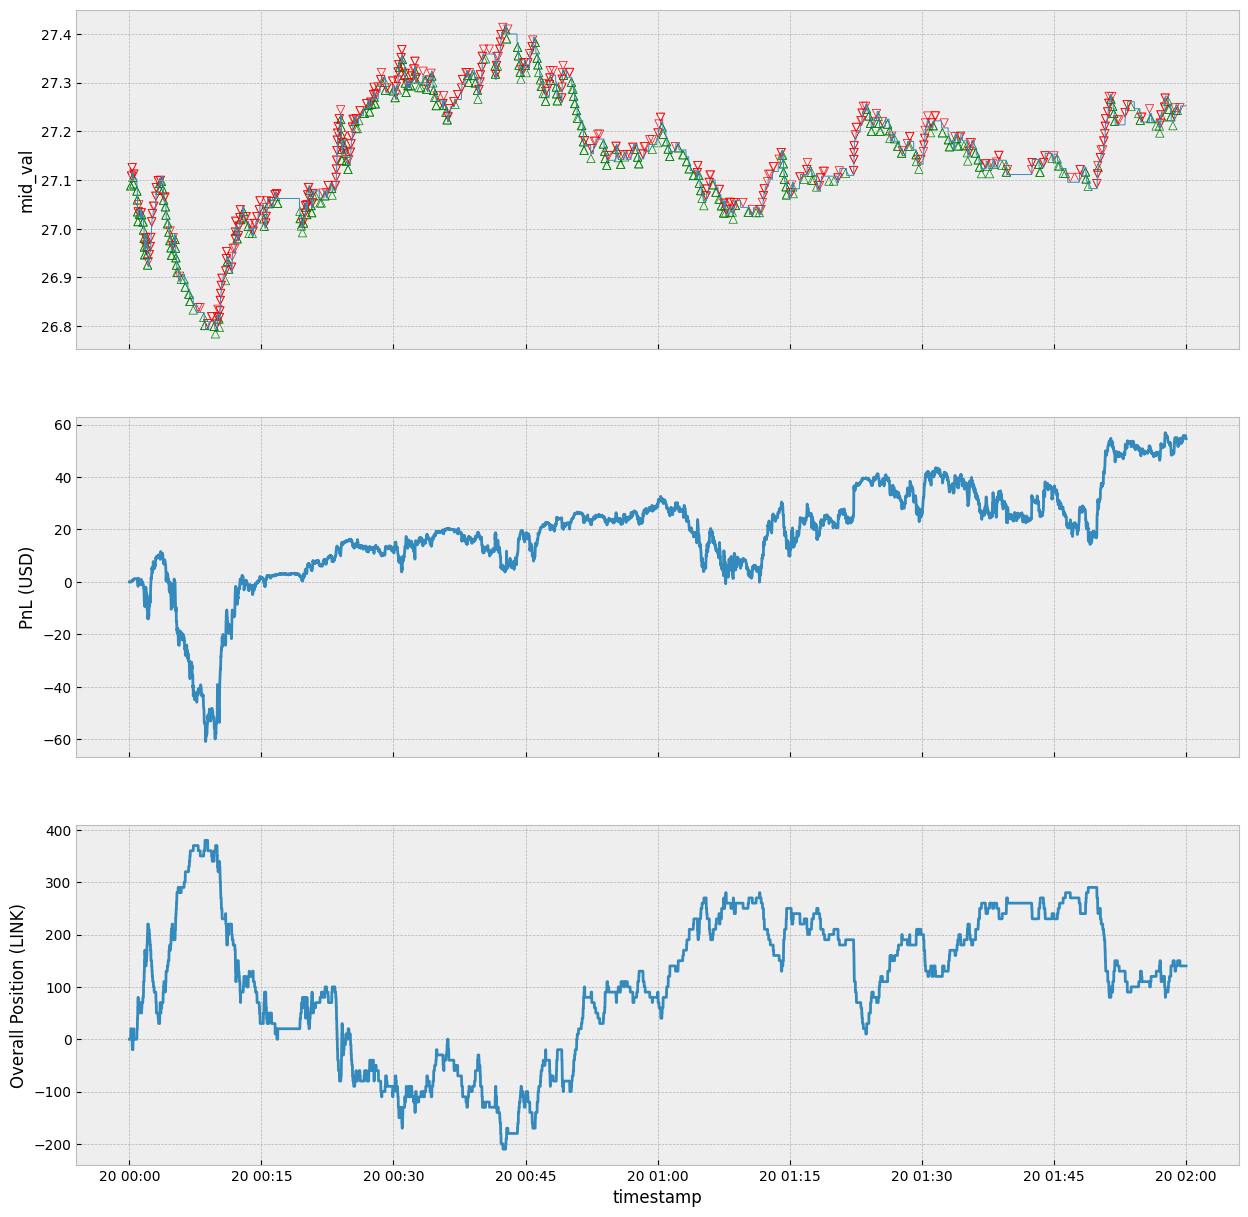

In [ ]:
order_logs, trade_logs, pos_record, risk_metrics = backtest_engine.run_backtest(
    order_offset=0.01,
    max_position=200,
    order_size=10,
    fill_threshold=2,
    bps_threshold=5
)

In [ ]:
print(f'PnL = {risk_metrics[0]:.2f} USD, \nMoons = {risk_metrics[1]:.6f}bps, \nMaximum Drawdown = {risk_metrics[2]:.2f} USD')

PnL = 54.55 USD, 
Moons = 0.000198bps, 
Maximum Drawdown = 72.46 USD


In [ ]:
order_logs

,Timestamp,Exchange,order_type,quote_price,order_size,market_b1,market_a1
0,2021-08-20 00:00:04,Binance,Bid,27.0881,10,27.0930,27.1010
1,2021-08-20 00:00:04,Binance,Ask,27.1081,10,27.0930,27.1010
2,2021-08-20 00:00:04,Huobi,Bid,27.0880,10,27.0923,27.0924
3,2021-08-20 00:00:04,Huobi,Ask,27.1080,10,27.0923,27.0924
4,2021-08-20 00:00:20,Binance,Bid,27.1057,10,27.1100,27.1320
...,...,...,...,...,...,...,...
1844,2021-08-20 01:59:04,Huobi,Ask,27.2481,10,27.2234,27.2328
1845,2021-08-20 01:59:22,Binance,Bid,27.2421,10,27.2500,27.2530
1846,2021-08-20 01:59:22,Binance,Ask,27.2621,10,27.2500,27.2530
1847,2021-08-20 01:59:22,Huobi,Bid,27.2420,10,27.2452,27.2565


In [ ]:
trade_logs

,Timestamp,Exchange,Side,trade_price,filled_volume,5s_markout,15s_markout,30s_markout,1m_markout,5m_markout
0,2021-08-20 00:00:10,Binance,Buy,27.0881,10,0.00,6.49,1.48,-21.74,-40.63
1,2021-08-20 00:00:10,Huobi,Buy,27.0880,10,0.00,6.49,1.48,-21.74,-40.63
2,2021-08-20 00:00:15,Binance,Sell,27.1081,10,6.49,1.48,1.48,-21.74,-47.20
3,2021-08-20 00:00:16,Huobi,Sell,27.1080,10,6.49,1.48,1.48,-21.74,-47.20
4,2021-08-20 00:00:20,Binance,Sell,27.1257,10,0.00,-5.02,-5.02,-34.33,-60.96
...,...,...,...,...,...,...,...,...,...,...
1009,2021-08-20 01:58:39,Binance,Sell,27.2316,10,6.02,11.42,6.10,11.20,NaN
1010,2021-08-20 01:58:43,Huobi,Sell,27.2479,10,5.40,5.40,0.07,5.18,NaN
1011,2021-08-20 01:58:48,Huobi,Buy,27.2426,10,0.00,0.00,-5.32,-0.22,NaN
1012,2021-08-20 01:59:00,Binance,Buy,27.2427,10,-5.32,-5.32,-0.22,NaN,NaN


In [ ]:
pos_record

,timestamp,Binance,Huobi,account_value
0,2021-08-20 00:00:00,0,0,5000.0000
1,2021-08-20 00:00:01,0,0,5000.0000
2,2021-08-20 00:00:02,0,0,5000.0000
3,2021-08-20 00:00:03,0,0,5000.0000
4,2021-08-20 00:00:04,0,0,5000.0000
...,...,...,...,...
7195,2021-08-20 01:59:55,110,30,5055.8190
7196,2021-08-20 01:59:56,110,30,5055.8190
7197,2021-08-20 01:59:57,110,30,5054.5045
7198,2021-08-20 01:59:58,110,30,5054.5220


# 2. Post-trade Analysis

Due to the simplicity of the strategy used in this report, which is essentially a pure market making strategy, we will not focus on the strategy improvement here. Instead, I will provide a few potential ideas for strategy-wise improvements:

- **Smarter pricing for mid_val**. The mid_val calculated in this report was just the moving average of the weighted mid price of ask1 and bid1. A potential improvements on this direction could be combining the bar data (which implied trading pulse signal) with the order book data from more level (which implied book pressure signal) to get a more sensible fair price as the mid_val.

- **Parameter Tuning.** The parameters used in this article, such as offset and order size, are simple fixed constants which were randomly decided, leaving significant room for optimization. For instance, dynamic adjustment of the offset could be considered.

- **Protective Action**. The strategy in this report does not take different actions for different scenarios. A direction for future improvements could involve implementing protective measures for specific market conditions. For example, when the market become extremely volatile , we could choose to withdraw all of our orders and stay way from the market for a while.


Regarding post-trade analysis, the perspective I choose is to compare trades between Binance and Huobi.

- From the following table, we can find that the trades number or the buy/sell ratio is pretty close on each exchange, which indicates that our trades are not affected by the different liquidty condition on the two exchanges, maybe it's because our trading size is too small.

- Another interesting pattern we can easily observe from the markout comparsion is that all of the markouts on Binance are better than Huobi, especially for the 5s_markout and 5m_markout, which indicates that the order flow on Huobi is worse than those on Binance for market makers.

In [ ]:
def buy_sell_ratio(series):
  return series.str.count('Buy').sum() / series.str.count('Sell').sum()

trade_logs.groupby('Exchange').agg({
    'Exchange': 'count',
    'Side': buy_sell_ratio,
    '5s_markout': 'mean',
    '15s_markout': 'mean',
    '30s_markout': 'mean',
    '1m_markout': 'mean',
    '5m_markout': 'mean'
})

,Exchange,Side,5s_markout,15s_markout,30s_markout,1m_markout,5m_markout
Exchange,,,,,,,
Binance,539,1.041667,0.360612,0.783358,0.833173,1.635781,0.252789
Huobi,475,1.012712,0.214400,0.750042,0.786547,1.312468,-0.706565
